In [1]:
from pathlib import Path
import pandas as pd

# Notebook hem proje ana klasöründen hem notebooks klasöründen çalışabilir.
project_dir = Path.cwd()
if not (project_dir / "data" / "processed").exists():
    project_dir = project_dir.parent

processed_dir = project_dir / "data" / "processed"
train_df = pd.read_csv(processed_dir / "hbtrain.csv")
test_df = pd.read_csv(processed_dir / "hbtest.csv")

print("Train veri boyutu:", train_df.shape)
print("Test veri boyutu:", test_df.shape)

X_train = train_df["temiz_metin"]
y_train = train_df["label"]

X_test = test_df["temiz_metin"]
y_test = test_df["label"]

Train veri boyutu: (196767, 2)
Test veri boyutu: (49192, 2)


In [2]:
##metinleri sayılara çevirir .
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf = TfidfVectorizer(
    max_features=50000, ## max kelime sayısı
    ngram_range=(1, 2), ## 1 ve 2 kelimelik n-gramlar
    min_df=2, ## en az 2 defa geçen kelimeler
    max_df=0.95, ## en fazla 0.95 oranında geçen kelimeler
    sublinear_tf=True ## çok fazla tekrarı dengelendirir 
)


In [3]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


print("Train TF-IDF boyutu:", X_train_tfidf.shape)
print("Test TF-IDF boyutu:", X_test_tfidf.shape)

Train TF-IDF boyutu: (196767, 50000)
Test TF-IDF boyutu: (49192, 50000)


In [4]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

##MultinomialNB, metin sınıflandırmaya uygun Naive Bayes türüdür.

nb_model.fit(X_train_tfidf, y_train)

nb_tahminler = nb_model.predict(X_test_tfidf)
print("Tahmin sayısı:", len(nb_tahminler))
print("İlk 10 tahmin:", nb_tahminler[:10])

Tahmin sayısı: 49192
İlk 10 tahmin: [1 1 2 1 1 2 0 0 1 1]


In [5]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_tahminler)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7530899333224914


In [6]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        nb_tahminler,
        target_names=["Negatif", "Nötr", "Pozitif"]
    )
)

              precision    recall  f1-score   support

     Negatif       0.82      0.82      0.82     15401
        Nötr       0.64      0.61      0.63     15804
     Pozitif       0.79      0.82      0.80     17987

    accuracy                           0.75     49192
   macro avg       0.75      0.75      0.75     49192
weighted avg       0.75      0.75      0.75     49192



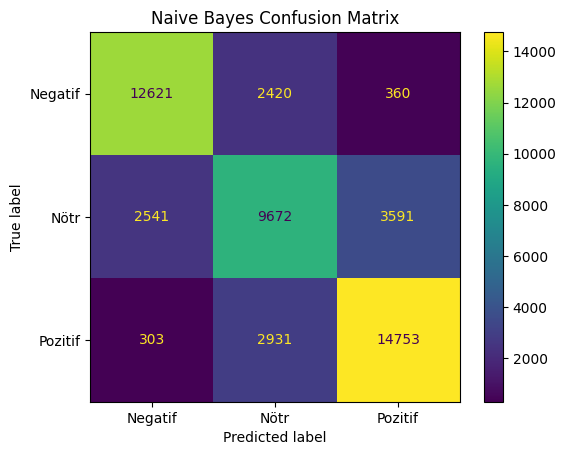

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_tahminler,
    display_labels=[
        "Negatif",
        "Nötr",
        "Pozitif"
    ]
)

plt.title(
    "Naive Bayes Confusion Matrix"
)
plt.show()

In [8]:
sonuclar_df = pd.DataFrame({
    "metin": X_test.values,
    "gercek": y_test.values,
    "tahmin": nb_tahminler
})

yanlislar = sonuclar_df[
    sonuclar_df["gercek"]
    != sonuclar_df["tahmin"]
]

yanlislar.head(20)

,metin,gercek,tahmin
3,herkese varda bana yokmuydu küçücük bir hediye...,2,1
8,gayet kullanışlı görünüyor elimize ulaştığında...,0,1
10,idare eder su akış gücüne extra bi tazyik yapm...,0,1
11,fiyat performans ürünü ürünü alalı 2 gün oldu ...,2,1
13,dört yıldız burada cam kutuda görünüyor bana p...,2,1
14,iyi fakat düzeltilmesi gereken noktalar var ür...,1,0
15,ürünün başlığıyla kendisi farklı! disk fren di...,0,1
21,ürün kalite ürün kaliteli ihtiyacı karşılar be...,1,2
22,yeni geldi ürün elime dün ulaştı yorumları oku...,1,2
25,güzel ayakkabi guzel sadece paket berbatti bir...,2,1


In [9]:
etiket_isimleri = {
    0: "Negatif",
    1: "Nötr",
    2: "Pozitif"
}

yanlislar = yanlislar.copy()

yanlislar["gercek_duygu"] = (
    yanlislar["gercek"]
    .map(etiket_isimleri)
)

yanlislar["tahmin_duygu"] = (
    yanlislar["tahmin"]
    .map(etiket_isimleri)
)

In [10]:
yanlislar[
    (yanlislar["gercek"] == 1)
    & (yanlislar["tahmin"] == 2)
].head(20)

,metin,gercek,tahmin,gercek_duygu,tahmin_duygu
21,ürün kalite ürün kaliteli ihtiyacı karşılar be...,1,2,Nötr,Pozitif
22,yeni geldi ürün elime dün ulaştı yorumları oku...,1,2,Nötr,Pozitif
29,gayet iyi gayet güzel çabuk pişiriyormağazalar...,1,2,Nötr,Pozitif
39,üç yıldız diğer markaları kullandım ama çap ol...,1,2,Nötr,Pozitif
81,güzel kitabı hepsiburadadan uygun fiyata aldım...,1,2,Nötr,Pozitif
96,kullanışlı bir ürün ürünü bir arkadaşımın evin...,1,2,Nötr,Pozitif
103,mendil güzel çok güzel mükemmel görüyorsunuz,1,2,Nötr,Pozitif
104,harika ürün ses kalitesi olarak harika kulakta...,1,2,Nötr,Pozitif
108,çalışmak gayet iyi 9 yaşındaki kızımı çalıştır...,1,2,Nötr,Pozitif
121,elime ulaştı cok güzel elime 2 günde ulaştı co...,1,2,Nötr,Pozitif


In [11]:
import joblib

models_dir = project_dir / "models"

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [12]:
joblib.dump(
    tfidf,
    models_dir / "tfidf_vectorizer.pkl"
)

['C:\\Users\\Muhammet Ali Balci\\OneDrive\\Masaüstü\\duyguanalizistaj\\models\\tfidf_vectorizer.pkl']

In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1,
    random_state=42
)
logistic_model.fit(X_train_tfidf, y_train)

joblib.dump(
    logistic_model,
    models_dir / "logistic_regression_model.pkl"
)

C:\Users\Muhammet Ali Balci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


['C:\\Users\\Muhammet Ali Balci\\OneDrive\\Masaüstü\\duyguanalizistaj\\models\\logistic_regression_model.pkl']

In [14]:
etiket_isimleri = {
    0: "Negatif",
    1: "Nötr",
    2: "Pozitif"
}

def duygu_tahmin_et(metin):
    metin_tfidf = tfidf.transform(
        [metin]
    )

    tahmin = logistic_model.predict(
        metin_tfidf
    )[0]

    return etiket_isimleri[tahmin]

In [15]:
duygu_tahmin_et(
    "Kalem deyip geçmemek lazım.  "
)

'Negatif'